# CCAnalyzer-style queue analysis — `cc_queue`

Three runs, single 64-packet pfifo bottleneck, 60 s each:

| # | CC | bandwidth | added latency |
|---|----|-----------|---------------|
| 1 | Cubic | 10 Mbps | 85 ms |
| 2 | BBR   | 10 Mbps | 275 ms |
| 3 | Reno  | 15 Mbps | 139 ms |

Plots below: **throughput**, **bottleneck queue occupancy** (packets), and
**normalized occupancy** (occupancy ÷ buffer size, à la CCAnalyzer). Plus an
**execution-time table** (intent-submission → data) with the declared 60 s
duration alongside. Data is read from `cc_results/` produced by
`run_cc_queue.sh`.


In [1]:
import sys, os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = '/home/jaber/agentic-thin-waist'
RESULTS = os.path.join(REPO, 'cc_results')
sys.path.insert(0, os.path.join(REPO, 'services', 'analysis'))
from queue_trace import load_queue_trace, summarize_queue_trace

BUFFER_PKTS = 64          # pfifo queue size shared by all three runs

RUNS = [
    {'tag': 'cubic_10bw-85rtt-64q',  'cc': 'cubic', 'bw': 10, 'rtt': 85,  'label': 'Cubic · 10 Mbps · 85 ms',  'color': 'tab:blue'},
    {'tag': 'bbr_10bw-275rtt-64q',   'cc': 'bbr',   'bw': 10, 'rtt': 275, 'label': 'BBR · 10 Mbps · 275 ms',   'color': 'tab:orange'},
    {'tag': 'reno_15bw-139rtt-64q',  'cc': 'reno',  'bw': 15, 'rtt': 139, 'label': 'Reno · 15 Mbps · 139 ms',  'color': 'tab:green'},
]
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})
print('reading from', RESULTS)

reading from /home/jaber/agentic-thin-waist/cc_results


In [2]:
def find_trace(tag):
    """Locate the queue-occupancy JSONL artifact for a run tag."""
    cands = [p for p in glob.glob(os.path.join(RESULTS, tag + '__*'))
             if (p.endswith('.jsonl') or 'queue' in os.path.basename(p).lower())
             and os.path.getsize(p) > 0]
    return sorted(cands, key=os.path.getsize, reverse=True)[0] if cands else None

def bottleneck_iface(df):
    """The interface where the queue actually builds = highest mean backlog."""
    return df.groupby('iface')['backlog_pkts'].mean().idxmax()

data = {}
for r in RUNS:
    p = find_trace(r['tag'])
    if not p:
        print('  MISSING queue trace for', r['tag'], '- run run_cc_queue.sh first'); continue
    df = load_queue_trace(p)
    if df.empty:
        print('  EMPTY trace for', r['tag']); continue
    iface = bottleneck_iface(df)
    sub = df[df['iface'] == iface].sort_values('rel_t').reset_index(drop=True)
    data[r['tag']] = {'df': sub, 'iface': iface, 'meta': r, 'path': p}
    s = summarize_queue_trace(df).get(iface, {})
    print(f"  {r['tag']:26s} iface={iface} samples={len(sub):5d} "
          f"dur={sub['rel_t'].max():.1f}s mean_q={s.get('backlog_pkts',{}).get('mean',0):.1f}pkt")
assert data, 'No traces loaded — run run_cc_queue.sh (with sudo) first.'

  cubic_10bw-85rtt-64q       iface=veth2 samples=12001 dur=60.0s mean_q=46.7pkt


  bbr_10bw-275rtt-64q        iface=veth2 samples=12001 dur=60.0s mean_q=6.7pkt


  reno_15bw-139rtt-64q       iface=veth2 samples=12001 dur=60.0s mean_q=29.2pkt


## 1 · Throughput
Delivered throughput at the bottleneck, derived from the qdisc `bytes_sent` counters (dequeue rate). Raw 5 ms samples faded; ~1 s rolling mean bold; dashed line = configured link rate.

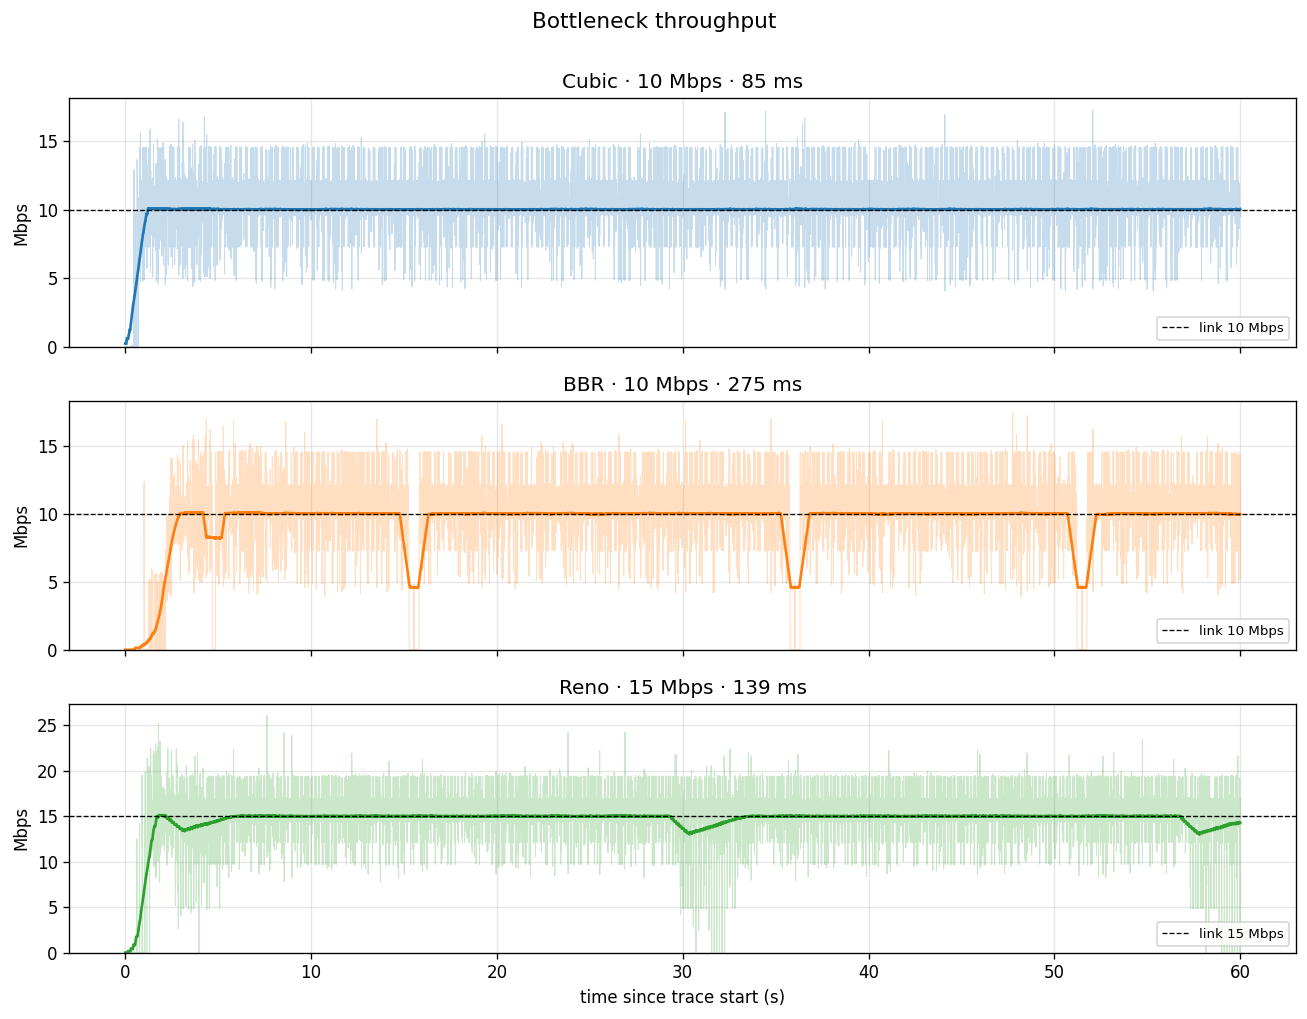

In [3]:
fig, axes = plt.subplots(len(data), 1, figsize=(11, 2.8*len(data)), sharex=True)
if len(data) == 1: axes = [axes]
for ax, (tag, d) in zip(axes, data.items()):
    sub, m = d['df'], d['meta']
    dt = sub['rel_t'].diff().median() or 0.005
    win = max(1, int(round(1.0/dt)))
    thr = sub['throughput_mbps_from_qdisc']
    ax.plot(sub['rel_t'], thr, color=m['color'], alpha=0.25, lw=0.6)
    ax.plot(sub['rel_t'], thr.rolling(win, min_periods=1, center=True).mean(),
            color=m['color'], lw=1.6)
    ax.axhline(m['bw'], color='k', ls='--', lw=0.8, label=f"link {m['bw']} Mbps")
    ax.set_title(m['label']); ax.set_ylabel('Mbps'); ax.legend(loc='lower right', fontsize=8)
    ax.set_ylim(bottom=0)
axes[-1].set_xlabel('time since trace start (s)')
fig.suptitle('Bottleneck throughput', y=1.005, fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, 'fig_throughput.png'), dpi=140, bbox_inches='tight')
plt.show()

## 2 · Queue occupancy (packets)
Bottleneck backlog in packets over time. Dashed line = 64-packet buffer. This is the raw CCAnalyzer signal — the per-CCA sawtooth / probing shape.

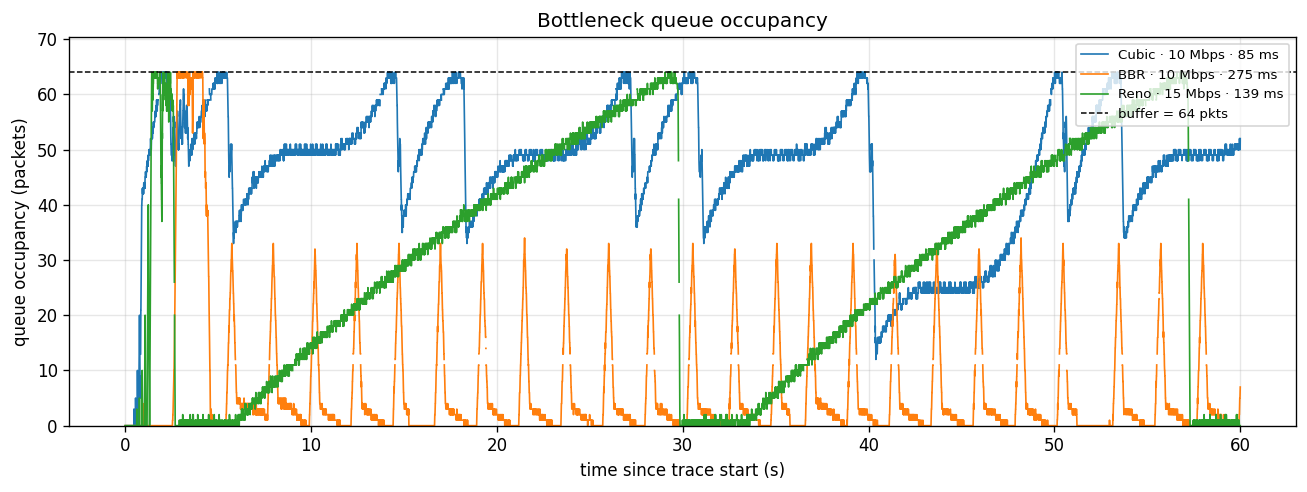

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.2))
for tag, d in data.items():
    sub, m = d['df'], d['meta']
    ax.plot(sub['rel_t'], sub['backlog_pkts'], lw=1.0, color=m['color'], label=m['label'])
ax.axhline(BUFFER_PKTS, color='k', ls='--', lw=0.9, label=f'buffer = {BUFFER_PKTS} pkts')
ax.set_xlabel('time since trace start (s)'); ax.set_ylabel('queue occupancy (packets)')
ax.set_title('Bottleneck queue occupancy'); ax.set_ylim(0, BUFFER_PKTS*1.1)
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, 'fig_queue_occupancy.png'), dpi=140, bbox_inches='tight')
plt.show()

## 3 · Normalized queue occupancy (occupancy ÷ buffer size)
Same traces normalized to the buffer size (64 pkts), so 1.0 = full queue — the CCAnalyzer normalization that makes different queue sizes comparable.

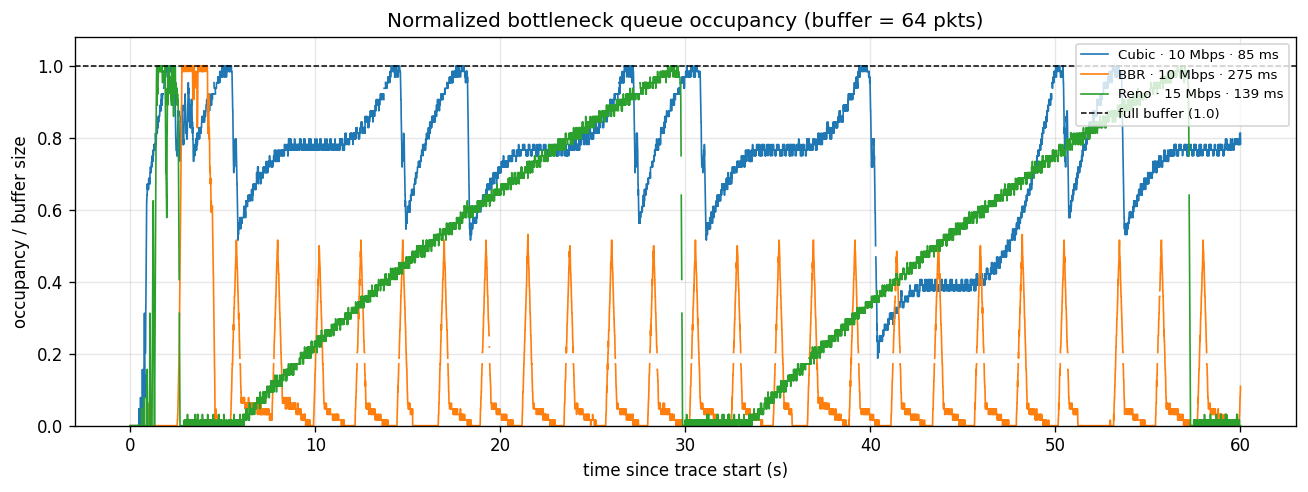

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.2))
for tag, d in data.items():
    sub, m = d['df'], d['meta']
    ax.plot(sub['rel_t'], sub['backlog_pkts'] / BUFFER_PKTS, lw=1.0, color=m['color'], label=m['label'])
ax.axhline(1.0, color='k', ls='--', lw=0.9, label='full buffer (1.0)')
ax.set_xlabel('time since trace start (s)'); ax.set_ylabel('occupancy / buffer size')
ax.set_title(f'Normalized bottleneck queue occupancy (buffer = {BUFFER_PKTS} pkts)')
ax.set_ylim(0, 1.08); ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, 'fig_queue_occupancy_normalized.png'), dpi=140, bbox_inches='tight')
plt.show()

## 4 · Execution time (intent submission → data) vs. declared duration
`exec_time_submit_to_data_s` is wall-clock from `POST /intent` to orchestration `complete` (includes worker spin-up, whole-minute-boundary wait, capture drain, telemetry upload). `intent_duration_s` is the 60 s declared in the intent.

In [6]:
tp = os.path.join(RESULTS, 'timing.csv')
t = pd.read_csv(tp)
# keep only successful runs; if a CC was retried, keep the latest complete row
t = t[t['status'] == 'complete'].drop_duplicates(subset=['cc', 'bw_mbps', 'rtt_ms'], keep='last')
t['wall_s'] = t['wall_s'].astype(float).round(2)
tbl = (t[['cc', 'bw_mbps', 'rtt_ms', 'queue_pkts', 'wall_s', 'declared_duration_s', 'status', 'experiment_id']]
       .rename(columns={'wall_s': 'exec_time_submit_to_data_s',
                        'declared_duration_s': 'intent_duration_s'}))
tbl['orchestration_overhead_s'] = (tbl['exec_time_submit_to_data_s'] - tbl['intent_duration_s']).round(2)
tbl.to_csv(os.path.join(RESULTS, 'execution_time_table.csv'), index=False)
display(tbl)

,cc,bw_mbps,rtt_ms,queue_pkts,exec_time_submit_to_data_s,intent_duration_s,status,experiment_id,orchestration_overhead_s
2,reno,15,139,64,146.78,60,complete,wget_15_15_139_pfifo_reno_dc721e3a,86.78
5,reno,5,85,64,166.93,60,complete,wget_5_5_85_pfifo_reno_ebb49367,106.93
6,cubic,5,85,64,182.18,60,complete,wget_5_5_85_pfifo_cubic_6b5a7a76,122.18
7,bbr,5,85,64,177.02,60,complete,wget_5_5_85_pfifo_bbr_9bc191b8,117.02
8,bic,5,85,64,182.03,60,complete,wget_5_5_85_pfifo_bic_02b579f8,122.03
...,...,...,...,...,...,...,...,...,...
180,scalable,5,275,1024,187.03,60,complete,wget_5_5_275_pfifo_scalable_57704c10,127.03
181,vegas,5,275,1024,177.07,60,complete,wget_5_5_275_pfifo_vegas_0a1d0036,117.07
182,veno,5,275,1024,182.05,60,complete,wget_5_5_275_pfifo_veno_1e7a0e6f,122.05
183,westwood,5,275,1024,171.96,60,complete,wget_5_5_275_pfifo_westwood_32a7efb3,111.96


---
# 5 · CCAnalyzer paper figures — full 15-CCA campaign

The three runs above are the small `run_cc_queue.sh` smoke test. The cells below
reproduce the paper's **queue-occupancy figures** from the **full** `run_cc_campaign.sh`
sweep in `cc_results/` (15 CCAs × 12 settings), reusing the loaders defined earlier
(`find_trace`, `load_queue_trace`, `bottleneck_iface`).

**Two versions of every figure.** For each paper figure we plot:
1. **Occupancy in packets** — the paper's own y-axis (Fig. 5/6 captions: *"queue occupancy … (pkts)"*).
2. **Normalized occupancy = occupancy ÷ buffer size** — the CCAnalyzer normalization
   (§3.3.2 / the paper normalizes across settings; here `1.0` = a full queue), which makes
   different queue sizes directly comparable on a `[0, 1]` scale. Same convention as §3 above.

| Figure | Paper | What it shows |
|---|---|---|
| Fig. 5 | Figure 5 | Cubic queue occupancy vs queue size (5 Mbps / 275 ms) |
| Fig. 6 | Figure 6 | BBR queue occupancy vs queue size (5 Mbps / 275 ms) |
| Fig. 1 | Figure 1 | Four CCAs are visually distinct (NewReno / BBR / Cubic / BIC) |
| Fig. 23 | Figure 23 | Example traces for all 15 CCAs at one setting |


In [7]:
# Paper-figure helpers — reuse find_trace / load_queue_trace / bottleneck_iface from above.
PAPER_NAME = {
    'reno': 'NewReno', 'cubic': 'Cubic', 'bbr': 'BBR', 'bic': 'BIC', 'cdg': 'CDG',
    'highspeed': 'Highspeed', 'htcp': 'HTCP', 'hybla': 'Hybla', 'illinois': 'Illinois',
    'nv': 'New Vegas', 'scalable': 'Scalable', 'vegas': 'Vegas', 'veno': 'Veno',
    'westwood': 'Westwood', 'yeah': 'Yeah',
}
ALL_CCS = list(PAPER_NAME)

def cc_tag(cc, bw, rtt, q):
    return f'{cc}_{bw}bw-{rtt}rtt-{q}q'

def load_bottleneck(tag):
    # backlog series on the bottleneck iface (veth2) for a run tag
    p = find_trace(tag)
    if not p:
        raise FileNotFoundError(f'no queue trace for {tag}')
    df = load_queue_trace(p)
    iface = bottleneck_iface(df)
    return df[df['iface'] == iface].sort_values('rel_t').reset_index(drop=True)

def plot_q(ax, tag, qcap, color='tab:blue', tmax=60, norm=False):
    # norm=False -> occupancy in packets (cap line at qcap)
    # norm=True  -> occupancy / buffer size   (cap line at 1.0)
    sub = load_bottleneck(tag)
    m = sub['backlog_pkts'].notna() & (sub['rel_t'] <= tmax)
    y = sub['backlog_pkts'][m]
    if norm:
        y = y / qcap
        ax.plot(sub['rel_t'][m], y, lw=0.7, color=color)
        ax.axhline(1.0, ls='--', color='crimson', lw=0.9)
        ax.set_ylim(0, 1.08)
    else:
        ax.plot(sub['rel_t'][m], y, lw=0.7, color=color)
        ax.axhline(qcap, ls='--', color='crimson', lw=0.9)
        ax.set_ylim(0, qcap * 1.08)
    ax.set_xlim(0, tmax)

print('paper-figure helpers ready — campaign runs found:',
      len(glob.glob(os.path.join(RESULTS, '*__queue_trace__*.jsonl'))))


paper-figure helpers ready — campaign runs found: 183


### Figure 5 — Cubic queue occupancy vs. queue size (5 Mbps, 275 ms)

Cubic is loss-based: it fills whatever queue you give it (backlog rides the red cap line),
so larger buffers → more bufferbloat. **Left/first plot = packets; second = normalized
(÷ buffer size).** In the normalized view every panel shares a `[0, 1]` axis, so you can
see Cubic saturates the buffer regardless of its absolute size.


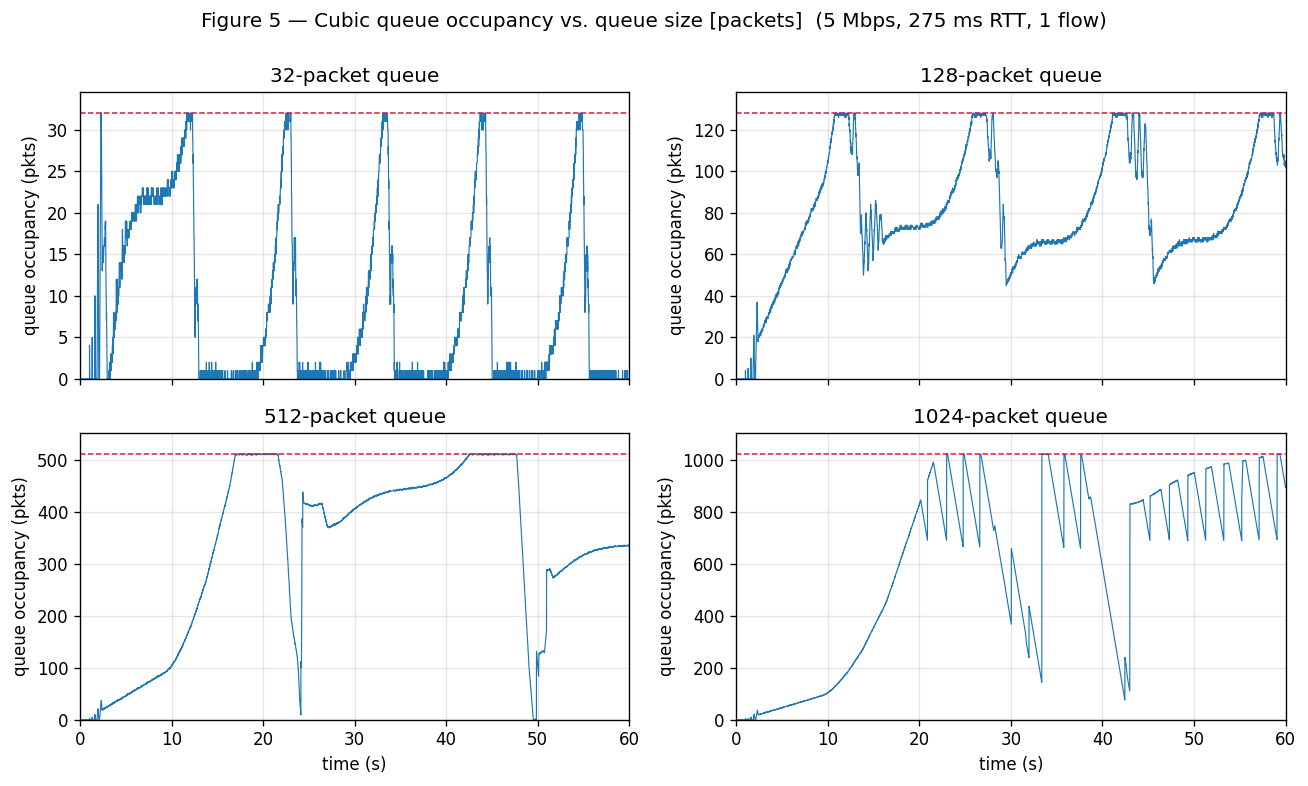

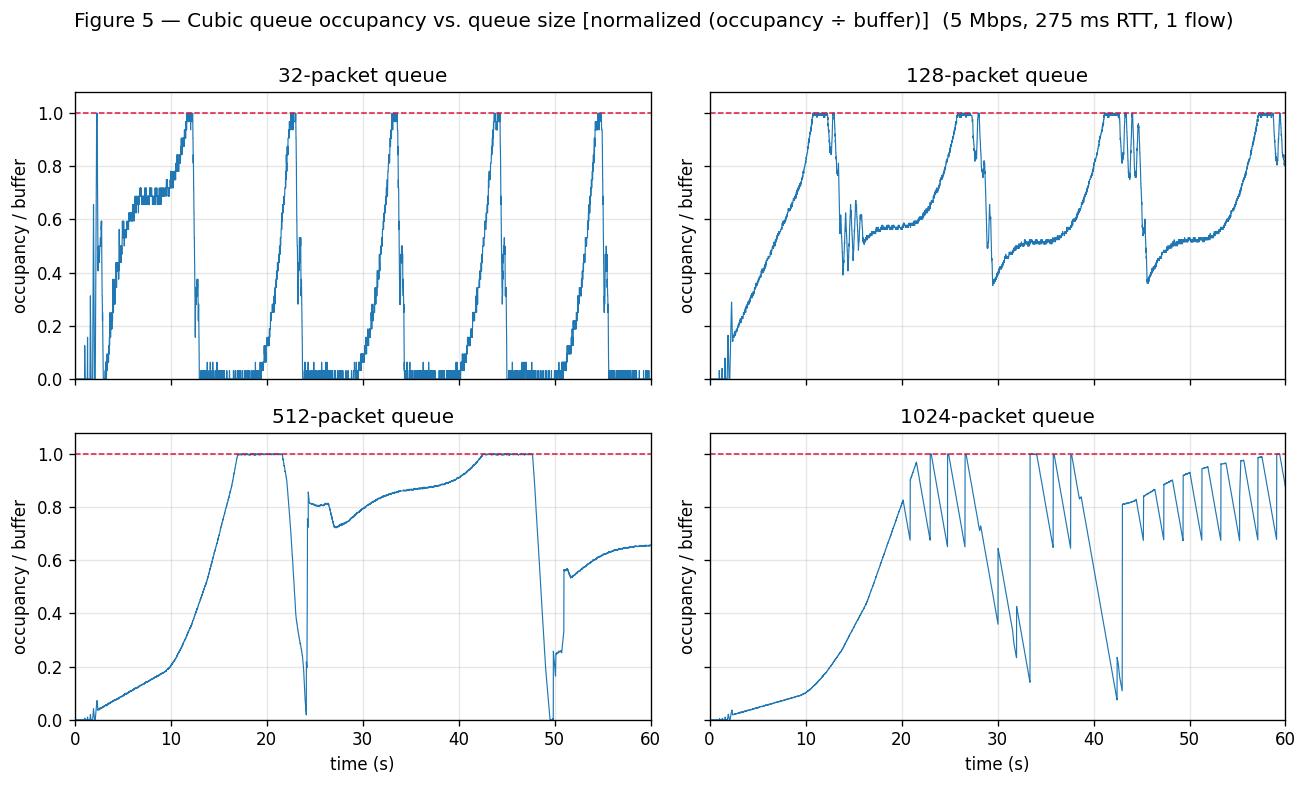

In [8]:
QS = [32, 128, 512, 1024]
def fig_queue_sweep(cc, color, num, norm):
    fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True, sharey=norm)
    for ax, q in zip(axes.flat, QS):
        plot_q(ax, cc_tag(cc, 5, 275, q), qcap=q, color=color, norm=norm)
        ax.set_title(f'{q}-packet queue')
        ax.set_ylabel('occupancy / buffer' if norm else 'queue occupancy (pkts)')
    for ax in axes[-1]:
        ax.set_xlabel('time (s)')
    kind = 'normalized (occupancy ÷ buffer)' if norm else 'packets'
    fig.suptitle(f'Figure {num} — {PAPER_NAME[cc]} queue occupancy vs. queue size '
                 f'[{kind}]  (5 Mbps, 275 ms RTT, 1 flow)', y=1.0)
    fig.tight_layout()
    suffix = '_normalized' if norm else ''
    fig.savefig(os.path.join(RESULTS, f'fig_paper0{num}_{cc}_queue_sweep{suffix}.png'),
                dpi=140, bbox_inches='tight')
    plt.show()

fig_queue_sweep('cubic', 'tab:blue', 5, norm=False)   # packets
fig_queue_sweep('cubic', 'tab:blue', 5, norm=True)    # normalized


### Figure 6 — BBR queue occupancy vs. queue size (5 Mbps, 275 ms)

BBR is model-based, so unlike Cubic it does **not** fill a large queue. The normalized
view drives the point home: at 512/1024 packets BBR sits far below `1.0`, whereas Cubic
(Fig. 5 normalized) hugs `1.0` in every panel.


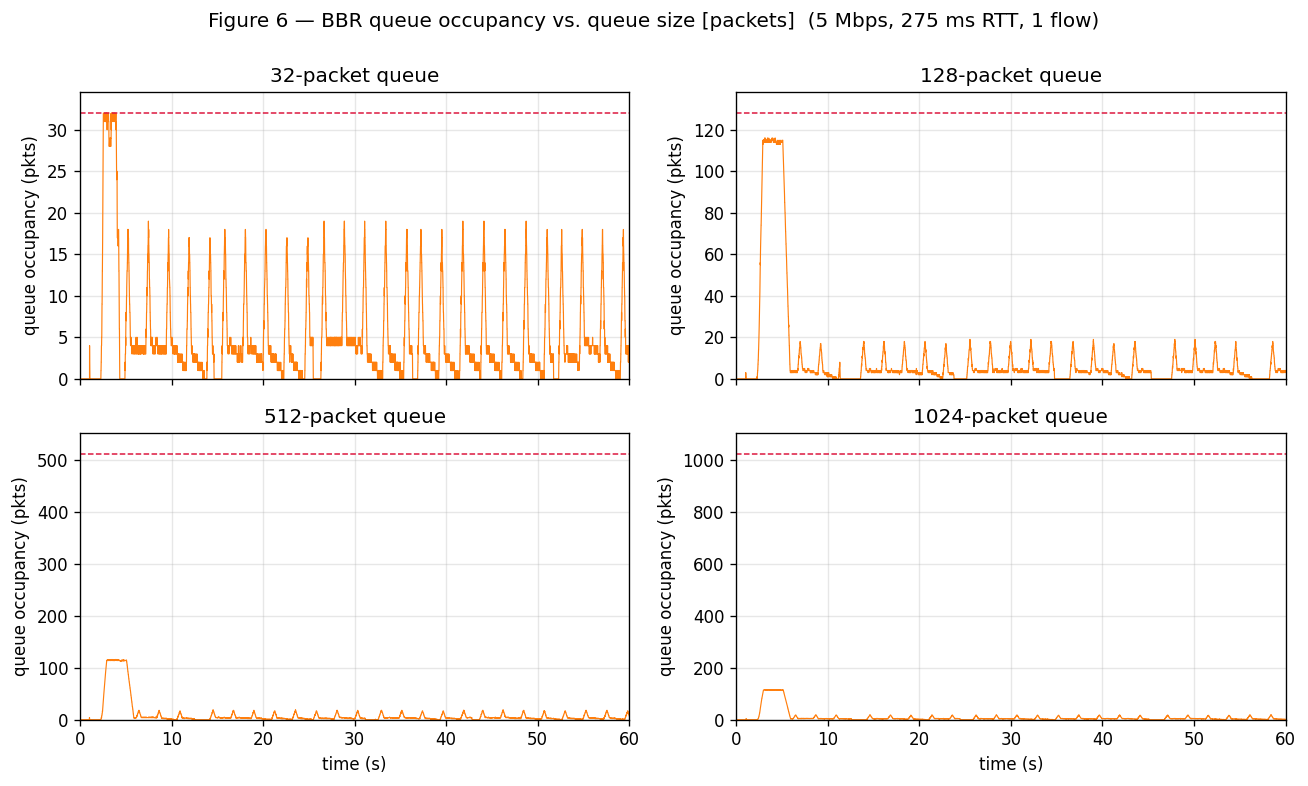

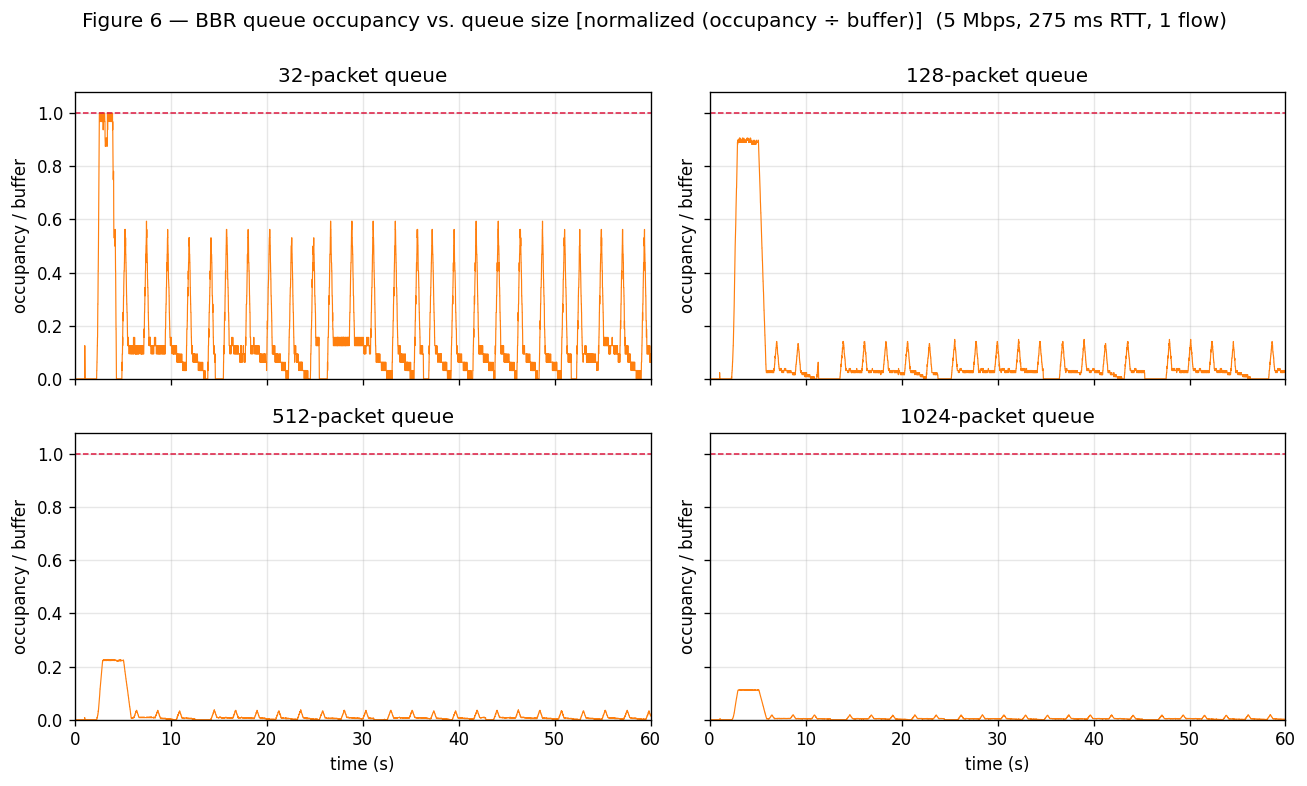

In [9]:
fig_queue_sweep('bbr', 'tab:orange', 6, norm=False)   # packets
fig_queue_sweep('bbr', 'tab:orange', 6, norm=True)    # normalized


### Figure 1 — Four CCAs are visually distinct (10 Mbps, 130 ms, 128-pkt)

Different CCAs leave visibly different queue signatures — the basis for 1NN-DTW
classification. Second plot = normalized (÷ 128-pkt buffer).


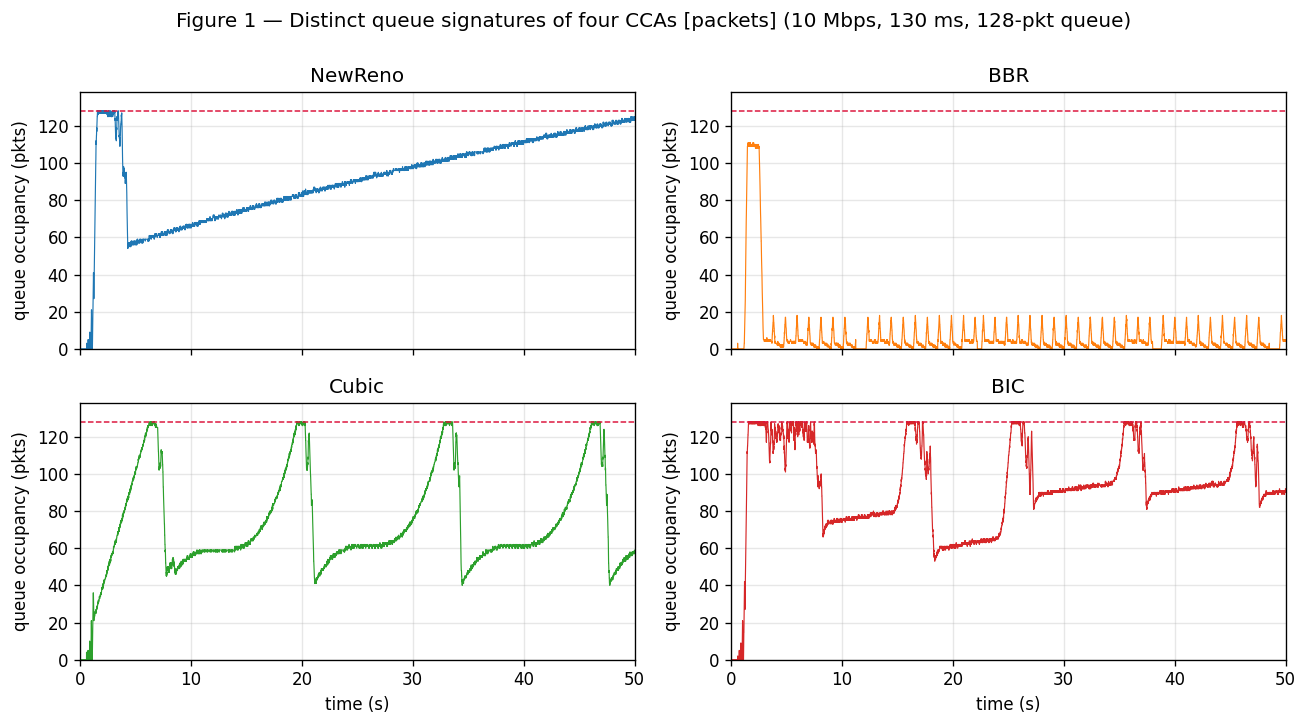

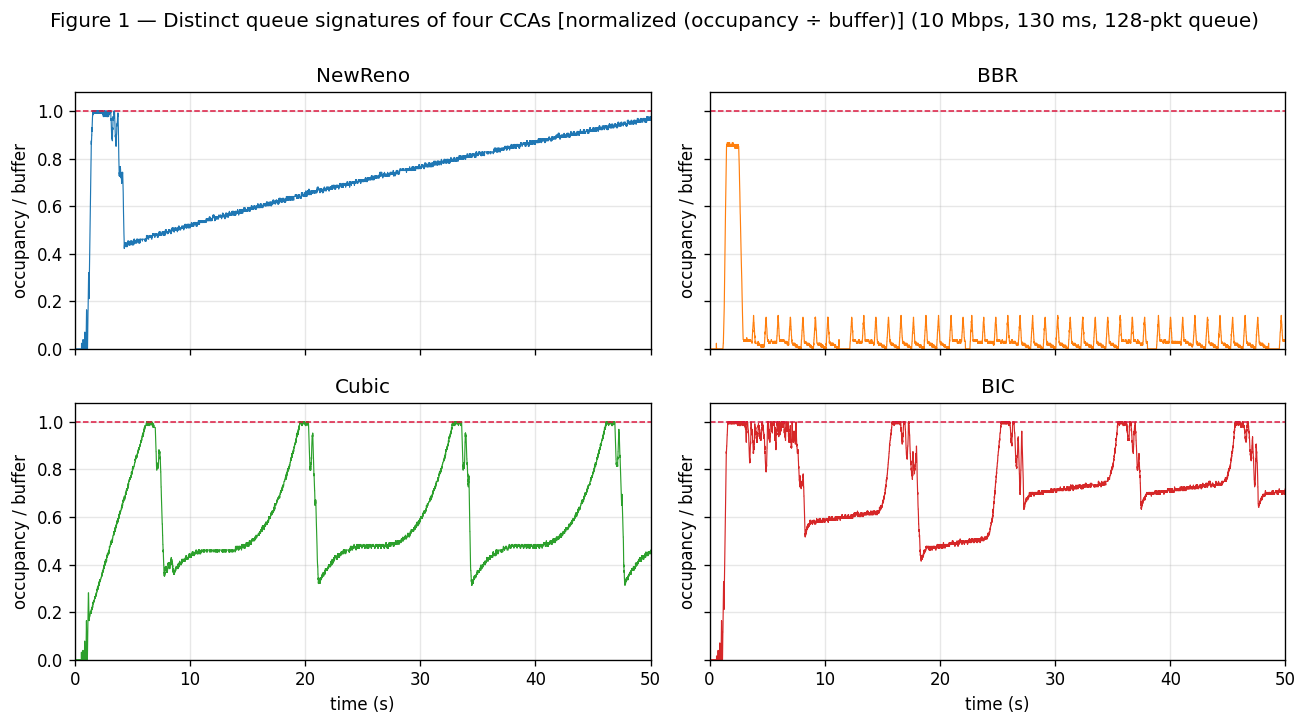

In [10]:
BW, RTT, Q = 10, 130, 128
FOUR = [('reno', 'tab:blue'), ('bbr', 'tab:orange'), ('cubic', 'tab:green'), ('bic', 'tab:red')]
def fig_four(norm):
    fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, sharey=norm)
    for ax, (cc, col) in zip(axes.flat, FOUR):
        plot_q(ax, cc_tag(cc, BW, RTT, Q), qcap=Q, color=col, tmax=50, norm=norm)
        ax.set_title(PAPER_NAME[cc])
        ax.set_ylabel('occupancy / buffer' if norm else 'queue occupancy (pkts)')
    for ax in axes[-1]:
        ax.set_xlabel('time (s)')
    kind = 'normalized (occupancy ÷ buffer)' if norm else 'packets'
    fig.suptitle(f'Figure 1 — Distinct queue signatures of four CCAs [{kind}] '
                 f'({BW} Mbps, {RTT} ms, {Q}-pkt queue)', y=1.0)
    fig.tight_layout()
    suffix = '_normalized' if norm else ''
    fig.savefig(os.path.join(RESULTS, f'fig_paper01_four_ccas{suffix}.png'),
                dpi=140, bbox_inches='tight')
    plt.show()

fig_four(norm=False)   # packets
fig_four(norm=True)    # normalized


### Figure 23 — Example traces for all 15 CCAs (5 Mbps, 85 ms, 64-pkt)

The full 15-CCA fingerprint gallery at the paper's `5bw-85rtt-64q` setting. Second plot =
normalized (÷ 64-pkt buffer), a shared `[0, 1]` axis across all 15 panels.


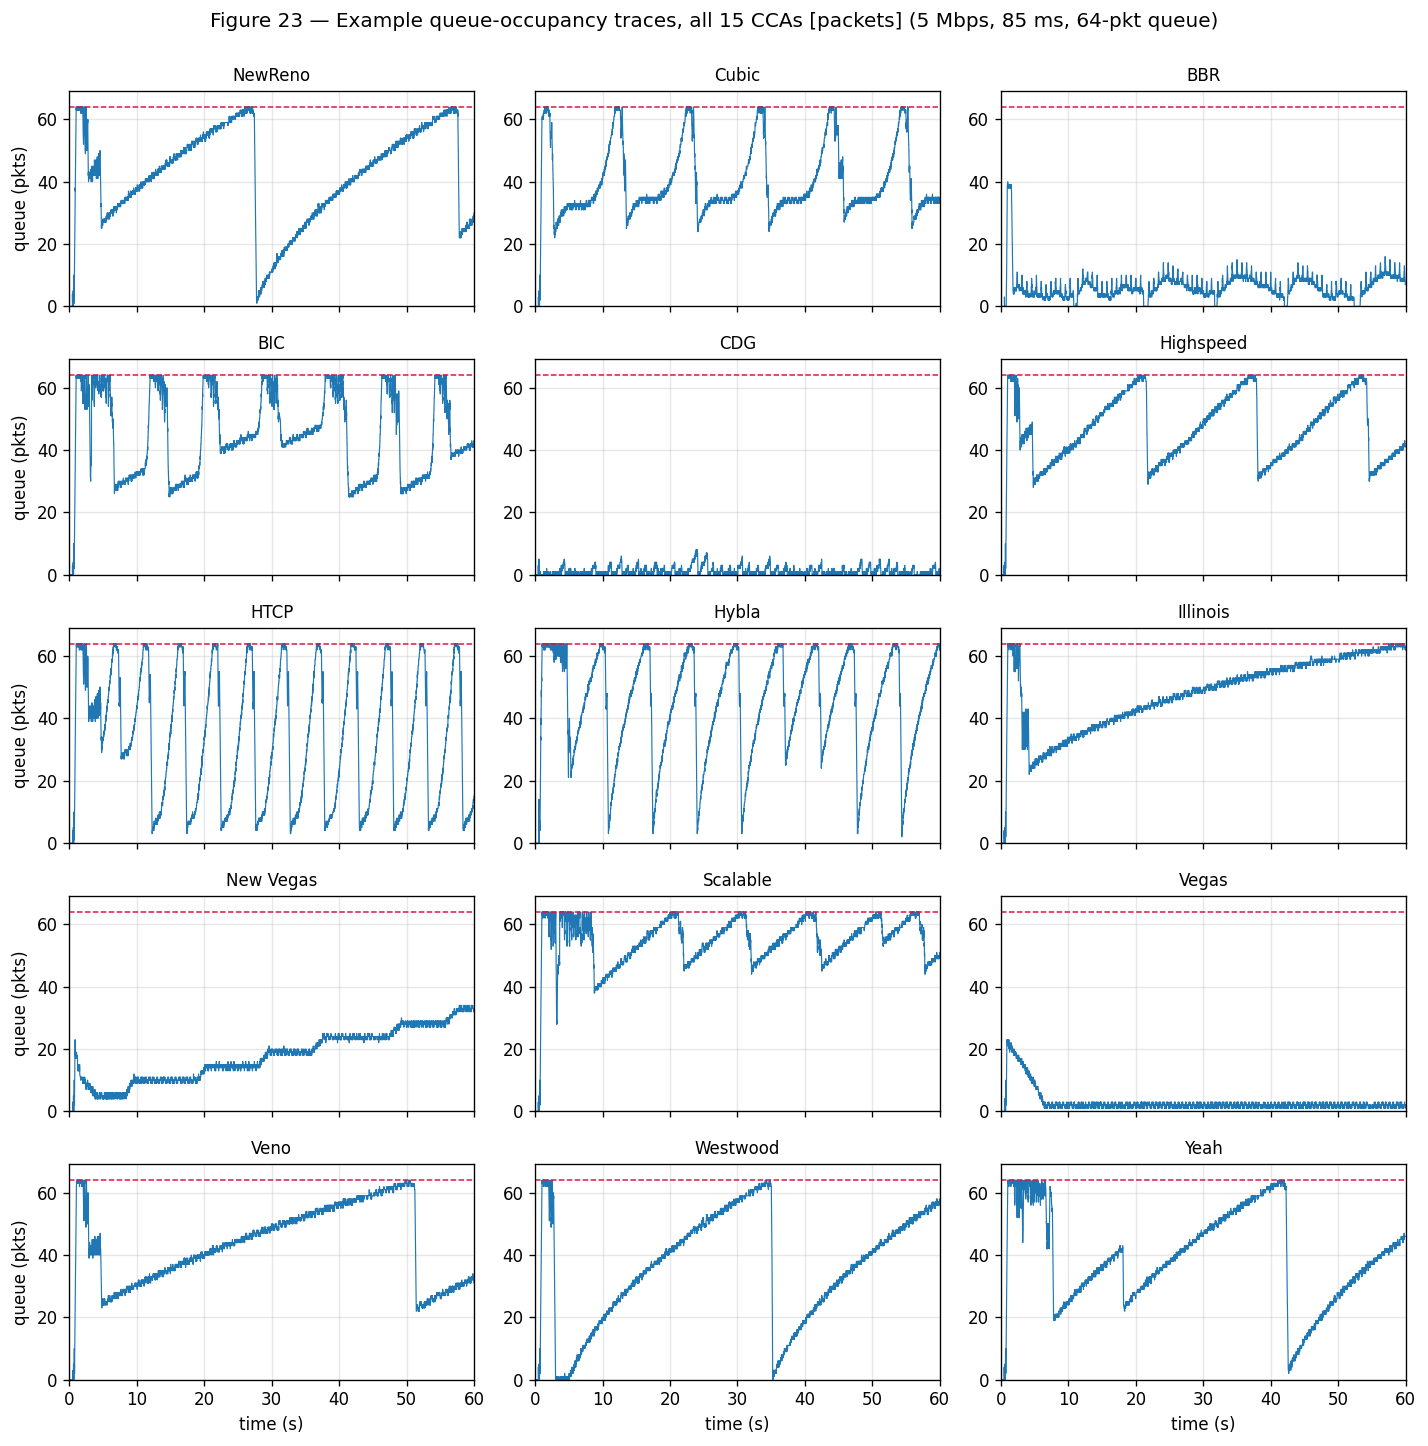

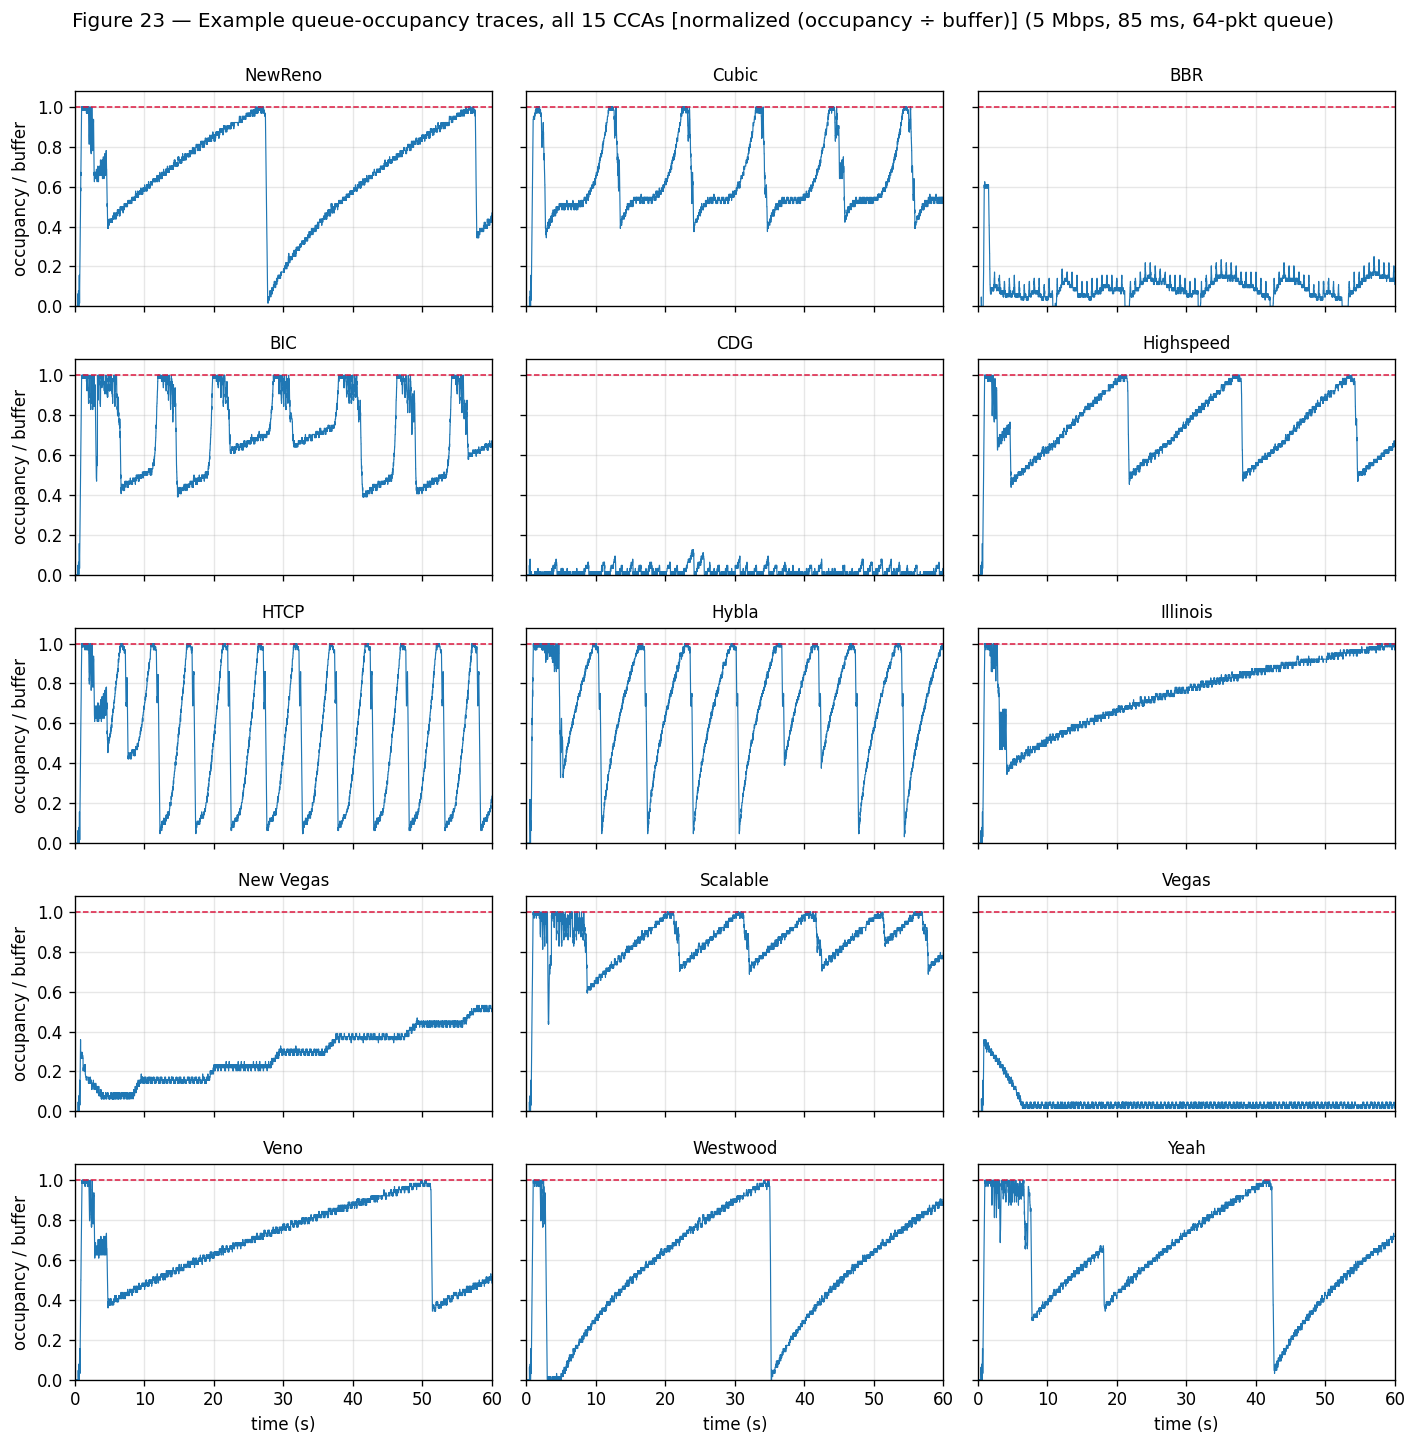

In [11]:
BW2, RTT2, Q2 = 5, 85, 64
def fig_gallery(norm):
    fig, axes = plt.subplots(5, 3, figsize=(12, 12), sharex=True, sharey=norm)
    for ax, cc in zip(axes.flat, ALL_CCS):
        try:
            plot_q(ax, cc_tag(cc, BW2, RTT2, Q2), qcap=Q2, color='tab:blue', norm=norm)
        except FileNotFoundError:
            ax.text(0.5, 0.5, f'{cc}\n(missing)', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(PAPER_NAME[cc], fontsize=10)
    for ax in axes[-1]:
        ax.set_xlabel('time (s)')
    for ax in axes[:, 0]:
        ax.set_ylabel('occupancy / buffer' if norm else 'queue (pkts)')
    kind = 'normalized (occupancy ÷ buffer)' if norm else 'packets'
    fig.suptitle(f'Figure 23 — Example queue-occupancy traces, all 15 CCAs [{kind}] '
                 f'({BW2} Mbps, {RTT2} ms, {Q2}-pkt queue)', y=1.0)
    fig.tight_layout()
    suffix = '_normalized' if norm else ''
    fig.savefig(os.path.join(RESULTS, f'fig_paper23_all15_ccas{suffix}.png'),
                dpi=140, bbox_inches='tight')
    plt.show()

fig_gallery(norm=False)   # packets
fig_gallery(norm=True)    # normalized


---
## 6 · CDF of orchestration overhead — (entire wall-clock − 60 s transfer)

`timing.csv` records, per run, `wall_s` = the **entire time** from `POST /intent` to the
orchestration flipping to `complete` (worker spin-up + CTP fetch + the 60 s transfer +
capture drain + telemetry upload). Subtracting the **60 s execution** (the declared
transfer duration) leaves the pure **orchestration overhead**. Below is its CDF across
every completed run in the campaign.


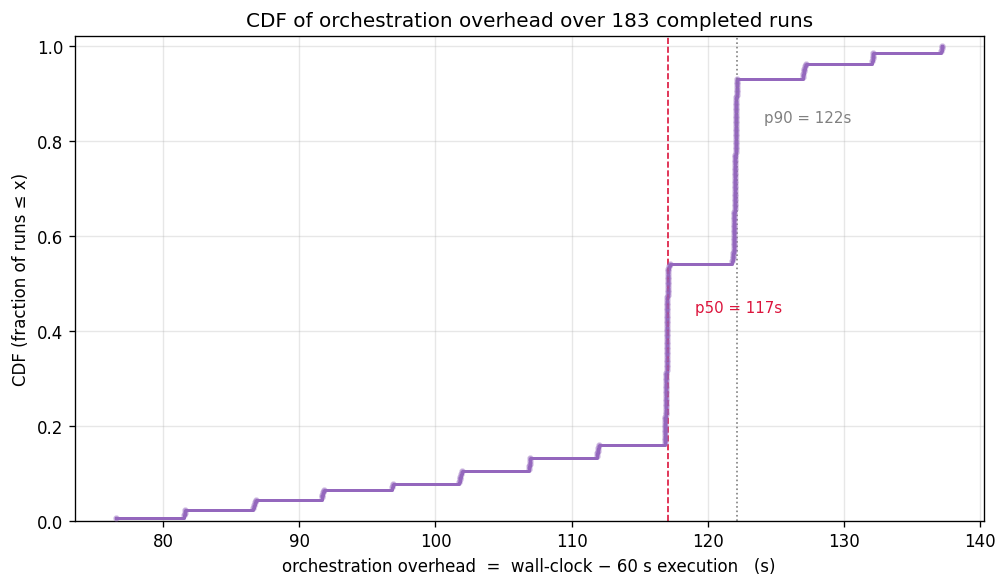

overhead (wall_s − 60) over 183 runs:
  min 76.5s   median 117.1s   mean 116.9s   p90 122.1s   max 137.2s


In [12]:
tv = pd.read_csv(os.path.join(RESULTS, 'timing.csv'))
tv = tv[tv['status'] == 'complete'].copy()
tv['wall_s'] = tv['wall_s'].astype(float)
tv['overhead_s'] = tv['wall_s'] - tv['declared_duration_s'].astype(float)  # entire time - 60s execution

x = np.sort(tv['overhead_s'].values)
y = np.arange(1, len(x) + 1) / len(x)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.step(x, y, where='post', lw=1.8, color='tab:purple')
ax.scatter(x, y, s=8, color='tab:purple', alpha=0.4, zorder=3)
for q, style in [(0.5, dict(color='crimson', ls='--')), (0.9, dict(color='gray', ls=':'))]:
    v = np.quantile(x, q)
    ax.axvline(v, lw=1.0, **style)
    ax.annotate(f'p{int(q*100)} = {v:.0f}s', xy=(v, q), xytext=(v + 2, q - 0.06),
                fontsize=9, color=style['color'])
ax.set_xlabel('orchestration overhead  =  wall-clock − 60 s execution   (s)')
ax.set_ylabel('CDF (fraction of runs ≤ x)')
ax.set_ylim(0, 1.02)
ax.set_title(f'CDF of orchestration overhead over {len(x)} completed runs')
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, 'fig_overhead_cdf.png'), dpi=140, bbox_inches='tight')
plt.show()

print('overhead (wall_s − 60) over %d runs:' % len(x))
print('  min %.1fs   median %.1fs   mean %.1fs   p90 %.1fs   max %.1fs'
      % (x.min(), np.median(x), x.mean(), np.quantile(x, 0.9), x.max()))
